In [1]:
!pip install gymnasium ale-py autorom


In [2]:
!AutoROM --accept-license


AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	C:\Users\zaria\anaconda3\Lib\site-packages\AutoROM\roms

Existing ROMs will be overwritten.


C:\Users\zaria\anaconda3\Lib\site-packages\AutoROM\AutoROM.py:264: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
!pip install pygame


In [4]:
!pip install opencv-python


In [5]:
%pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [2]:
import gymnasium as gym
import ale_py
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import torch
import torch.nn as nn
import torch.optim as optim


In [5]:
gym.register_envs(ale_py)

# Training env — RAM only, no rendering (rendering during training slows things down a lot)
env = gym.make("ALE/Freeway-v5", obs_type="ram")


In [6]:
# ---------------------------
# RAM MAP (verified against real game data)
# ---------------------------
# byte 14       = chicken Y position
#                  6   = bottom (start)
#                  174 = top (just before crossing)
#                  resets to 6 when crossing completes (env reward=1.0 fires)
# bytes 43-52   = car X position for each of the 10 lanes
#                  byte 43 = lane 0 (bottom), byte 52 = lane 9 (top)
# chicken X     = always 48 (horizontally fixed)
#
# Lane boundaries (from live RAM probing):
#   lane 0: y  6-21   (byte 43)
#   lane 1: y 22-37   (byte 44)
#   lane 2: y 38-53   (byte 45)
#   lane 3: y 54-69   (byte 46)
#   lane 4: y 70-85   (byte 47)
#   lane 5: y 86-101  (byte 48)
#   lane 6: y102-117  (byte 49)
#   lane 7: y118-133  (byte 50)
#   lane 8: y134-149  (byte 51)
#   lane 9: y150+     (byte 52)

CHICKEN_X = 48
DANGER_GAP = 30  # gap (in X units) below which a car is considered dangerous
                 # verified: cars with gap < ~30 reliably block upward movement

def get_lane(chicken_y):
    """Return which of the 10 lanes (0=bottom, 9=top) the chicken is in."""
    return max(0, min(9, (chicken_y - 6) // 16))

def get_car_gap(obs, chicken_y):
    """
    Return the horizontal distance between the chicken and the nearest car
    in the chicken's current lane.
    
    Cars move horizontally across each lane, so we read the X position
    from the correct RAM byte for the lane and compare to chicken_x=48.
    """
    lane = get_lane(chicken_y)
    car_x = int(obs[43 + lane])
    return abs(car_x - CHICKEN_X)

def is_in_danger(obs, chicken_y):
    """True if a car is dangerously close in the current lane."""
    return get_car_gap(obs, chicken_y) < DANGER_GAP


In [7]:
# ---------------------------
# NEURAL NETWORK
# ---------------------------
class MLP(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
    def forward(self, x):
        return self.net(x)

input_size  = 128
output_size = env.action_space.n  # 3: noop, up, down

model     = MLP(input_size, output_size)
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [8]:
# ---------------------------
# TRAINING 
# ---------------------------
RESET_TRAINING   = False   # True = start fresh, False = resume from checkpoint

episodes         = 3      # set to 1000-5000 for real training
gamma            = 0.99   # discount factor — makes agent care about future rewards
entropy_coef     = 0.01   # keeps the agent exploring instead of locking in too early
checkpoint_every = 0  # save every episode
YOUR_UP_ACTION_INDEX = 1
YOUR_DOWN_ACTION_INDEX = 2
step = 0

episode_rewards = []
start_episode   = 0

# ---------------------------
# CHECKPOINT LOADING
# ---------------------------
if not RESET_TRAINING:
    try:
        checkpoint = torch.load("checkpoint.pth", weights_only=True)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        episode_rewards = checkpoint.get("episode_rewards", [])
        start_episode   = checkpoint["episode"] + 1
        print(f"Resuming from episode {start_episode}")
    except FileNotFoundError:
        print("No checkpoint found, starting fresh.")
else:
    print("RESET_TRAINING = True → Starting from scratch")

# ---------------------------
# TRAINING LOOP
# ---------------------------
for episode in range(start_episode, episodes):
    obs, _ = env.reset()

    log_probs = []
    rewards   = []
    entropies = []
    prev_y    = None
    done      = False

    while not done:
        ram_input = torch.tensor(obs, dtype=torch.float32).unsqueeze(0) / 255.0

        logits = model(ram_input)
        probs  = torch.softmax(logits, dim=1)
        dist   = torch.distributions.Categorical(probs)

        action   = dist.sample()
        log_prob = dist.log_prob(action)
        entropy  = dist.entropy()

        obs, env_reward, term, trunc, _ = env.step(action.item())
        done = term or trunc
        chicken_y = int(obs[14])
        
        number_of_lanes = 10
        lane_height = 210 / number_of_lanes
        current_lane = int(chicken_y // lane_height)

        #print(f"Chicken Y: {chicken_y}, Current lane: {current_lane}")                # debug
        # ---------------------------
        # REWARD FUNCTION
        # ---------------------------
        # Based on verified RAM layout:
        #   byte 14     = chicken Y (higher = closer to goal)
        #   bytes 43-52 = car X per lane
        #   crossing    = env gives reward=1.0 when chicken reaches the top
        #
        # Design goals:
        #   1. Reward forward progress
        #   2. Reward smart waiting (standing still when a car is close)
        #   3. Penalize dumb waiting (standing still in a clear lane)
        #   4. Big bonus for completing a crossing

        # Car X in current lane
        car_x_current = int(obs[43 + current_lane])
        gap_current = abs(car_x_current - CHICKEN_X)

        # Car X in lane above
        lane_above_x = None
        if current_lane < 9:
            lane_above_x = int(obs[43 + current_lane + 1])

        # Car X in lane below
        lane_below_x = None
        if current_lane > 0:
            lane_below_x = int(obs[43 + current_lane - 1])

        # -----------------------------------------------------------------------------------------Debug prints
        #print(f"Lane {current_lane}: car_x={car_x_current}, gap={gap_current}")
        #if lane_above_x is not None:
            #print(f"Lane above ({current_lane+1}): car_x={lane_above_x}, gap={abs(lane_above_x - CHICKEN_X)}")
        #if lane_below_x is not None:
            #print(f"Lane below ({current_lane-1}): car_x={lane_below_x}, gap={abs(lane_below_x - CHICKEN_X)}")          # debug
        
        # ----------------------------------------------------------------------------------------------

        # Danger in current lane
        # Assuming you already have:
        # gap_current, car_x_current, CHICKEN_X defined

        if gap_current < DANGER_GAP:
            in_front = (car_x_current > CHICKEN_X)
        else:
            in_front = False

        #print(f"[DEBUG] in_front: {in_front} (car_x: {car_x_current}, chicken_x: {CHICKEN_X}, gap: {gap_current})")  # debug
        
        if lane_above_x is not None:
            if abs(lane_above_x - CHICKEN_X) < DANGER_GAP:
                block_up = True

        if lane_below_x is not None:
            if abs(lane_below_x - CHICKEN_X) < DANGER_GAP:
                block_down = True

        # Debug prints ----------------------------------------------------------------------------
        # print(f"in_front: {in_front}, block_up: {block_up}, block_down: {block_down}")
        #print(f"Decision: {decision}")
        # -------------------------------------------------------------------------------------------------------
        #print(f"Action: {action.item()}, Prob: {probs[0][action.item()]}")
        # After calculating danger                  ---------------------------------------debug
        #print(f"Y: {chicken_y}, Lane: {current_lane}")
        #print(f"Car X: {car_x_current}, Gap: {gap_current}")
        #print(f"in_front: {in_front}, block_up: {block_up}, block_down: {block_down}")
        #print(f"Delta: {delta}")
        #print(f"Agent is {'waiting' if delta == 0 else 'moving'}")
        #print("-" * 40)

        #print(f"[DEBUG] in_front: {in_front} (car_x: {car_x_current}, chicken_x: {CHICKEN_X}, gap: {gap_current})")
        #print(f"[DEBUG] danger: {danger}")
        # ---------------------------------------------------------------------------------------------------------
        if 'prev_y' not in locals() or prev_y is None:
            prev_y = chicken_y

        # Calculate delta after getting new chicken_y
        delta = chicken_y - prev_y
        decision = 'waiting' if delta == 0 else 'moving'
        # Determine danger
        danger = gap_current < DANGER_GAP
        #print(f"[DEBUG] in_front: {in_front} (car_x: {car_x_current}, chicken_x: {CHICKEN_X}, gap: {gap_current})")  # debugs
        #print(f"[DEBUG] danger (after setting): {danger}")                                                           # debugs
        
        # Then your reward logic
        if danger:
            if delta == 0:
                # Waiting in danger: big penalty
                reward = -5.0
            elif env_reward == 1.0:
                # Crossed successfully, still good
                reward = 5.0
            elif delta > 0:
                # Moved up in danger: penalty
                reward = -5
            elif delta < 0:
                # Moving down in danger: small penalty
                reward = -1
        else:
            # No danger
            if env_reward == 1.0:
                reward = 5.0
            elif delta > 0:
                reward = float(delta)  # reward for moving up
            elif delta < 0:
                reward = float(delta) + 0.3  # reward for moving down
            else:
                # Waiting when lane is clear - small penalty to encourage progress
                reward = -0.2

        prev_y = chicken_y

        log_probs.append(log_prob)
        rewards.append(reward)
        entropies.append(entropy)
        # ----------------------------------------------------------------------------------------
        #step += 1                                                            # debug
        #print(f"Step {step} | Reward: {reward}")                          # debug
        #print(f"chicken_y: {chicken_y}, prev_y: {prev_y}")
        # ---------------------------------------------------------------------------------------

    # ---------------------------
    # DISCOUNTED RETURNS
    # ---------------------------
    # G_t = r_t + γ*r_{t+1} + γ²*r_{t+2} + ...
    # This gives credit to early actions (like waiting) that enabled
    # safe crossing steps later in the episode.
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)
    # Normalize: keeps loss scale stable regardless of episode length
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ---------------------------
    # BASELINE
    # ---------------------------
    # Subtract recent average so the agent learns relative improvement,
    # not just whether the raw reward was positive
    baseline = float(np.mean(episode_rewards[-50:])) if len(episode_rewards) >= 50 else 0.0

    # ---------------------------
    # POLICY UPDATE
    # ---------------------------
    loss = torch.tensor(0.0, requires_grad=True)
    for lp, G_t, ent in zip(log_probs, returns, entropies):
        advantage = G_t - baseline
        loss = loss + (-lp * advantage) + (-entropy_coef * ent)

    optimizer.zero_grad()
    loss.backward()
    # Gradient clipping: prevents one bad episode from wrecking the weights
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    total_reward = sum(rewards)
    episode_rewards.append(total_reward)
    print(f"Episode {episode:>5} | Reward: {total_reward:>8.2f}")

    if checkpoint_every == 0:
                                      # Save after every episode
        torch.save({
            "episode": episode,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "episode_rewards": episode_rewards,
        }, "checkpoint.pth")
        print(f"  → Checkpoint saved at episode {episode}")

torch.save(model.state_dict(), "freeway_mlp.pth")
print("\nTraining complete. Model saved to freeway_mlp.pth")
env.close()


Resuming from episode 3

Training complete. Model saved to freeway_mlp.pth


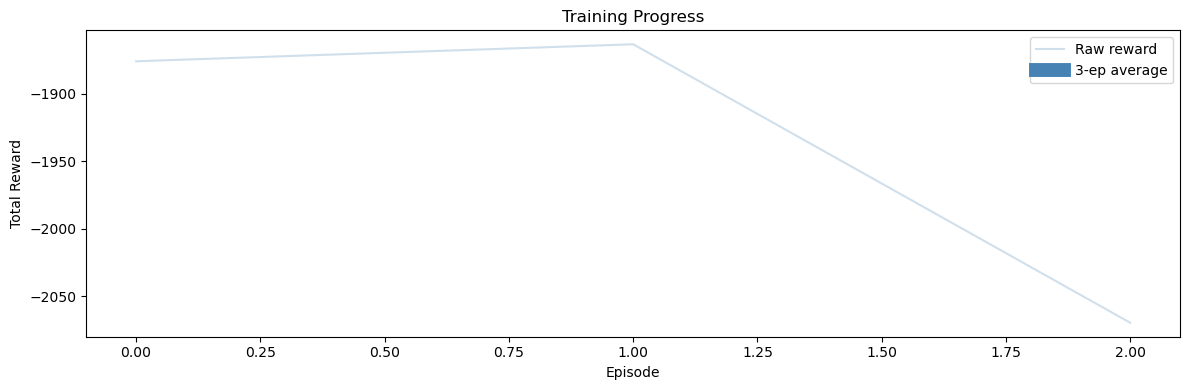

In [9]:
# ---------------------------
# TRAINING PROGRESS PLOT
# ---------------------------
# Raw reward per episode + 50-ep smoothed average.
# Look for:
#   - Upward trend = agent improving
#   - Plateau early = increase entropy_coef to keep exploring
#   - Reward spikes = crossing bonuses kicking in (good!)
# Assuming episode_rewards is your list of rewards per episode

# Load your checkpoint
checkpoint = torch.load("checkpoint.pth")

# Extract the episode_rewards list
episode_rewards = checkpoint["episode_rewards"]

# Set your smoothing window
window = 50

# Plotting with your actual data
if len(episode_rewards) >= 2:
    current_window = min(window, len(episode_rewards))
    if len(episode_rewards) >= current_window:
        smoothed = np.convolve(episode_rewards, np.ones(current_window)/current_window, mode='valid')
        x_vals = list(range(current_window - 1, len(episode_rewards)))
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(episode_rewards, alpha=0.25, color='steelblue', label='Raw reward')
        ax.plot(x_vals, smoothed, color='steelblue', linewidth=10, label=f'{current_window}-ep average')
    else:
        # Not enough data for smoothing; just plot raw rewards
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(episode_rewards, alpha=0.25, color='steelblue', label='Raw reward')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title('Training Progress')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Run more episodes to see a meaningful plot.")

In [ ]:
# ---------------------------
# PLAY LOOP
# ---------------------------
# Two environments in lockstep:
#   env_vis = RGB frames for display
#   env_ram = RAM observations for the model
# Same seed + joint reset keeps them in sync.

env_vis = gym.make("ALE/Freeway-v5", render_mode="human")
env_ram = gym.make("ALE/Freeway-v5", obs_type="ram")

obs_vis, _ = env_vis.reset(seed=42)
obs_ram, _ = env_ram.reset(seed=42)

model.load_state_dict(torch.load("freeway_mlp.pth", weights_only=True))
model.eval()
#rint("Model loaded. Summary:", model)            # debug
#print("Observation RAM shape:", obs_ram.shape)
#print("Observation RAM sample:", obs_ram[:5])  # print first few values

while True:
    ram_input = torch.tensor(
        np.array(obs_ram, dtype=np.float32) / 255.0
    ).unsqueeze(0)
    
    #print("RAM input tensor:", ram_input)  # debug
    #print("RAM input shape:", ram_input.shape)
    #output = model(ram_input)
    #print("Model output:", output)
    #print("Predicted action:", torch.argmax(output, dim=1).item())
    #action = torch.argmax(output, dim=1).item()
    # -------------------------------------------------------------------------debug up there
    with torch.no_grad():
        action = torch.argmax(model(ram_input), dim=1).item()

    obs_vis, _, term1, trunc1, _ = env_vis.step(action)
    obs_ram, _, term2, trunc2, _ = env_ram.step(action)

    frame_bgr = cv2.cvtColor(obs_vis.copy(), cv2.COLOR_RGB2BGR)
    cv2.imshow("Freeway AI", frame_bgr)
    time.sleep(0.03)
    

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    #print(f"Action taken: {action}") #                  dubug
    #print("Observation RAM:", obs_ram)
    
    if term1 or trunc1 or term2 or trunc2:
        obs_vis, _ = env_vis.reset(seed=42)
        obs_ram, _ = env_ram.reset(seed=42)

env_vis.close()
env_ram.close()
cv2.destroyAllWindows()
